# Parcial Analitica de datos 
En el siguiente notebookn se realizará todo el proceso de Data Wrangling y EDA a la data entregada de vinos adjuntas como archivos .csv

Primero importamos todas las librerias relevantes para nuestro analisis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

Ahora cargamos la data desde nuestros dos archivos. En este caso tenemos vino rojo y vino blanco.
Primero revisamos como están separadas las columnas en nuestros archivos.

In [ ]:
# Revisa el archivo para revisar que separador se usa, en este caso es ";"
with open("winequality-red.csv", "r") as file:
    print(file.readline())

"fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"



In [4]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

Ahora creamos una nueva columna como 'tipo de vino' para que al momento de unir los dos datasets aun sepamos que tipo de vino es

In [8]:
red["wine_type"] = "red"
white["wine_type"] = "white"

Ahora unimos los dos datasets, tomé está decisión ya que es más fácil trabar con un solo dataset que con varios en simultaneo

In [11]:
df = pd.concat([red, white], ignore_index=True)
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo_vino,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,red


In [26]:
# Muestra cuantas filas y columnas tiene el dataframe
df.shape

(5320, 14)

# Identificar y manejar valores faltantes o nulos

In [ ]:
#Aquí vamos a primero asegurar que cualquier dato faltante se marque como NaN, y luego pedir que nos de un conteo de cuantos NaN hay por cada columna.
df.replace("?", np.nan, inplace = True)
missing_data = df.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")  

fixed acidity
fixed acidity
False    6497
Name: count, dtype: int64

volatile acidity
volatile acidity
False    6497
Name: count, dtype: int64

citric acid
citric acid
False    6497
Name: count, dtype: int64

residual sugar
residual sugar
False    6497
Name: count, dtype: int64

chlorides
chlorides
False    6497
Name: count, dtype: int64

free sulfur dioxide
free sulfur dioxide
False    6497
Name: count, dtype: int64

total sulfur dioxide
total sulfur dioxide
False    6497
Name: count, dtype: int64

density
density
False    6497
Name: count, dtype: int64

pH
pH
False    6497
Name: count, dtype: int64

sulphates
sulphates
False    6497
Name: count, dtype: int64

alcohol
alcohol
False    6497
Name: count, dtype: int64

quality
quality
False    6497
Name: count, dtype: int64

tipo_vino
tipo_vino
False    6497
Name: count, dtype: int64

wine_type
wine_type
False    6497
Name: count, dtype: int64



In [22]:
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
tipo_vino               0
wine_type               0
dtype: int64

In [ ]:
# Ahora vamos a pedir un resumen estadístico de las columnas numéricas del dataframe.
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


Ahora normalizamos el nombre de nuestras columnas. Esto convierte los nombres de columnas a minúscula y cambia espacios por _.

In [20]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,tipo_vino,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,red


Ahora revisamos si tenemos datos duplicados y en caso tal de tenerlo eliminamos los datos duplicados.

In [25]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# Revision de tipos de datos
Ahora revisamos que el tipo de datos sea correcto y tambien los valores que contienen sean los estandar para la variable que evaluan.
En este caso  Se verificaron los tipos de datos del dataset y se observó que las variables numéricas estaban correctamente definidas como float64 e int64 y que que la variable tipo_vino encuentra como object, lo cual es correcto para una variable categórica.

Posteriormente haciendo una busqueda en internet, pude validar que los rangos de las variables seleccionadas estén de acuerdo con el estandar. Por ejemplo la variable alcohol presenta valores entre 8.0 y 14.9, y volatile_acidity tuvo valores entre 0.08 y 1.58. Estos rangos son coherentes con valores esperados en vinos reales. 

In [28]:
df[["quality", "alcohol", "volatile_acidity"]].describe()

,quality,alcohol,volatile_acidity
count,5320.000000,5320.000000,5320.000000
mean,5.795677,10.549241,0.344130
std,0.879772,1.185933,0.168248
min,3.000000,8.000000,0.080000
25%,5.000000,9.500000,0.230000
50%,6.000000,10.400000,0.300000
75%,6.000000,11.400000,0.410000
max,9.000000,14.900000,1.580000


In [27]:
df.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
tipo_vino                   str
wine_type                   str
dtype: object

# Analisis a variables de interes elegidas
En este proyecto he decidido que las variables de interés serán:
- tipo_vino
- quality
- alcohol
- volatile_acidity

In [29]:
variables_interes = [
    "tipo_vino",
    "quality",
    "alcohol",
    "volatile_acidity"
]

# Tipo de vino (tipo_vino)

Se analiza la cantidad de vinos de cada tipo:

vino rojo (red)
vino blanco (white)

Esto permite entender cómo está distribuido el dataset, permite comparar diferencias entre vinos rojos y blancos.

In [30]:
df["tipo_vino"].value_counts()

tipo_vino
white    3961
red      1359
Name: count, dtype: int64

Mostramos el conteo usando un Countplot. Se usa un countplot porque:
- la variable es categórica
- queremos contar frecuencias
- las barras permiten comparar cantidades fácilmente

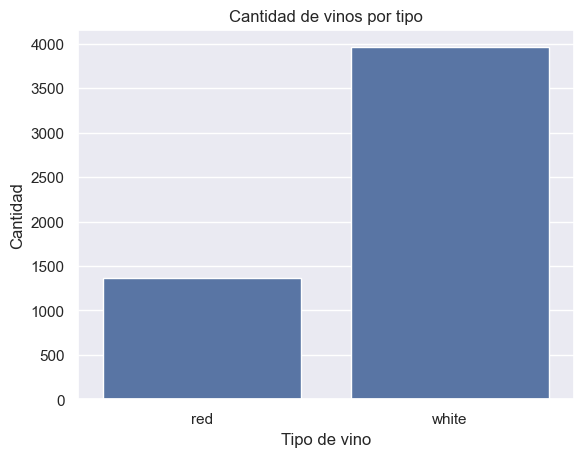

In [31]:
sns.countplot(data=df, x="tipo_vino")
plt.title("Cantidad de vinos por tipo")
plt.xlabel("Tipo de vino")
plt.ylabel("Cantidad")
plt.show()

<h3>Conclusion:</h3>

El dataset contiene más vinos blancos que vinos rojos. Esto indica un desbalance entre categorías, por lo que en comparaciones posteriores el vino blanco puede generar barras más altas en algunos gráficos.

# Calidad (quality)

Se analiza cómo se distribuyen los niveles de calidad del vino. Permite identificar:

- cuáles niveles de calidad son más frecuentes
- si predominan vinos buenos, malos o intermedios

Con un proceso de binning se distribuiran las calificaiones en estas categorias así:
- 3 y 4 son calidad mala
- 5 y 6 son calidad intermedia
- 7, 8 y 9 son calidad buena

In [32]:
df["quality"].value_counts().sort_index()

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

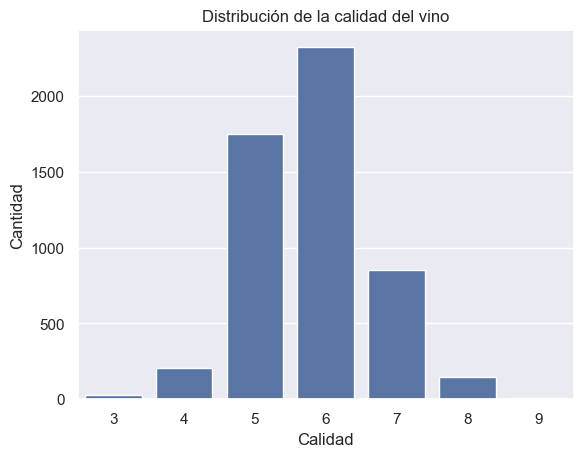

In [33]:
sns.countplot(data=df, x="quality")
plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Cantidad")
plt.show()

In [ ]:
bins_quality = [2, 4, 6, 9]

labels_quality = ["Malo", "Intermedio", "Bueno"]

df["categoria_quality"] = pd.cut(
    df["quality"],
    bins=bins_quality,
    labels=labels_quality
)

df["categoria_quality"].value_counts()

categoria_quality
Intermedio    4075
Bueno         1009
Malo           236
Name: count, dtype: int64

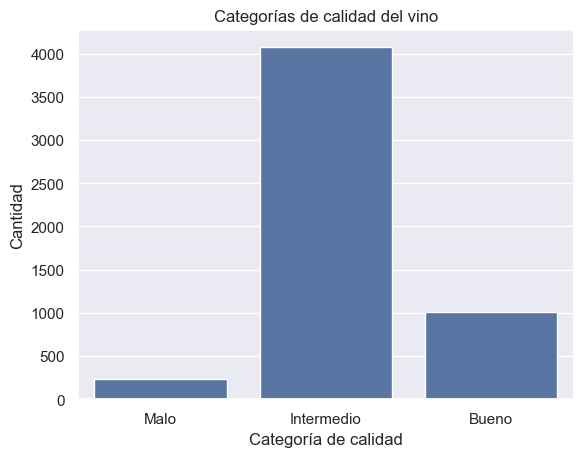

In [42]:
sns.countplot(data=df, x="categoria_quality")
plt.title("Categorías de calidad del vino")
plt.xlabel("Categoría de calidad")
plt.ylabel("Cantidad")
plt.show()

<h3>Conclusion </h3>
La mayoría de vinos pertenece a la categoría Intermedio, lo cual coincide con la distribución original de quality donde predominaban los valores 5 y 6.
Existen menos vinos clasificados como Buenos y muy pocos vinos considerados Malos.

# Porcentaje de alcohol (alcohol)
Se analiza:
- cómo se distribuyen los niveles de alcohol
- si existen valores extremos
- cómo cambia el alcohol según el tipo de vino y la calidad

Para mostrar esta data se utiliza un histograma porque:
- alcohol es una variable continua
- queremos observar la distribución de frecuencias
- permite detectar concentración de valores y posibles outliers

Con un proceso de binning también se pondran en categorias según el porcentaje de alcohol siendo:
- 8.7 Bajo
- 10.9 Medio
- 13.1 Alto


In [34]:
df["alcohol"].describe()

count    5320.000000
mean       10.549241
std         1.185933
min         8.000000
25%         9.500000
50%        10.400000
75%        11.400000
max        14.900000
Name: alcohol, dtype: float64

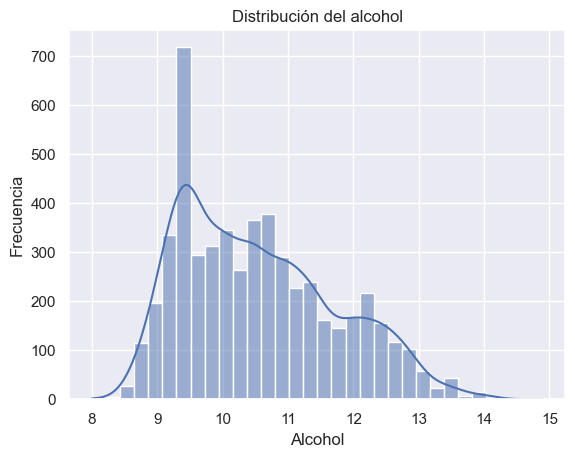

In [35]:
sns.histplot(data=df, x="alcohol", kde=True)
plt.title("Distribución del alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.show()

In [44]:
bins_alcohol = [8, 10, 12, 15]

labels_alcohol = ["Bajo", "Medio", "Alto"]

df["nivel_alcohol"] = pd.cut(
    df["alcohol"],
    bins=bins_alcohol,
    labels=labels_alcohol,
    include_lowest=True
)
df["nivel_alcohol"].value_counts()

nivel_alcohol
Medio    2372
Bajo     2205
Alto      743
Name: count, dtype: int64

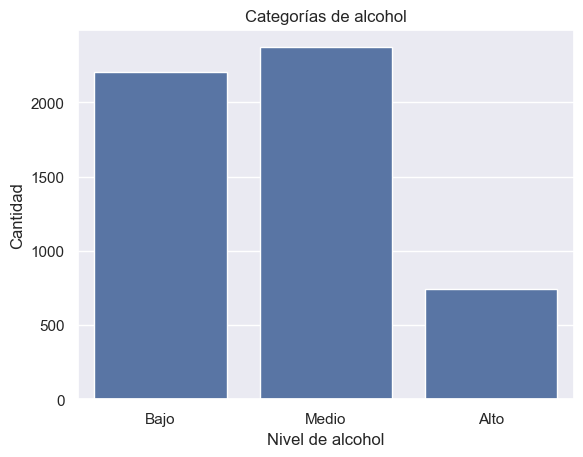

In [45]:
sns.countplot(data=df, x="nivel_alcohol")

plt.title("Categorías de alcohol")
plt.xlabel("Nivel de alcohol")
plt.ylabel("Cantidad")

plt.show()

<h3> Conclusion </h3>
La mayoría de vinos se concentra en categorías de alcohol Bajo e Intermedio. Existen menos vinos con niveles altos de alcohol.

# Analisis entre variables Alcohol y Calidad

Aqui queremos ver como cambia la calidad del vino según el nivel de alcohol. Ahora que hemos convertido las dos variables en variables categoricas


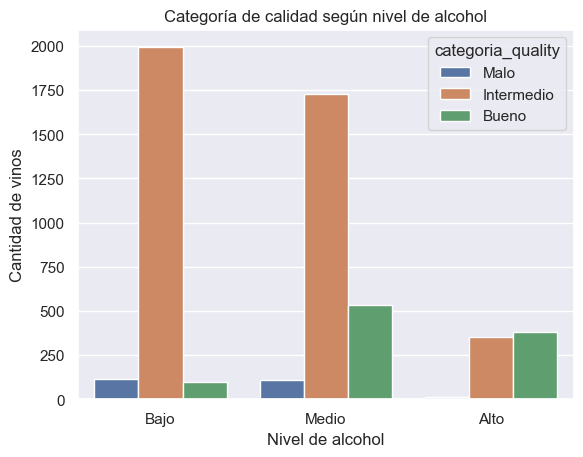

In [47]:
sns.countplot(
    data=df,
    x="nivel_alcohol",
    hue="categoria_quality"
)

plt.title("Categoría de calidad según nivel de alcohol")
plt.xlabel("Nivel de alcohol")
plt.ylabel("Cantidad de vinos")

plt.show()

<h3> Conclusion </h3>

- Los vinos con niveles altos de alcohol presentan una mayor proporción de vinos clasificados como Buenos.
- Los vinos con alcohol bajo se concentran principalmente en categorías Intermedias o Malas.

Existe una relación positiva entre alcohol y calidad del vino.

# Acidez volatil (volatile_acidity)

Esta variable fue elegida para el analisís porque la acidez volátil puede afectar negativamente el sabor y calidad del vino. En esta categoria se analiza:
- distribución
- dispersión
- relación con quality
- diferencias entre tipos de vino

In [37]:
df["volatile_acidity"].describe()

count    5320.000000
mean        0.344130
std         0.168248
min         0.080000
25%         0.230000
50%         0.300000
75%         0.410000
max         1.580000
Name: volatile_acidity, dtype: float64

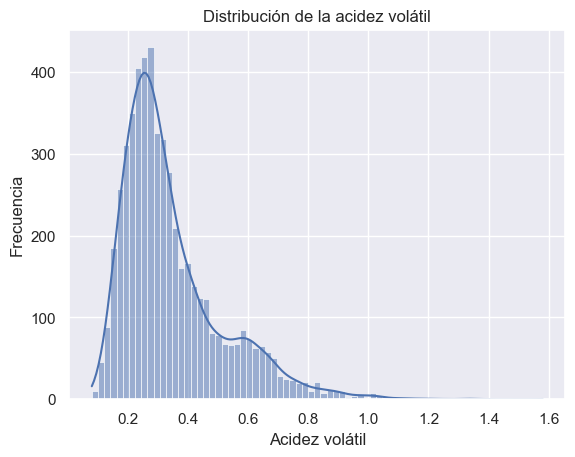

In [38]:
sns.histplot(data=df, x="volatile_acidity", kde=True)
plt.title("Distribución de la acidez volátil")
plt.xlabel("Acidez volátil")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de vinos presenta niveles bajos de acidez volátil.

Algunos vinos muestran valores más altos, lo que podría relacionarse con menor calidad.

# Acidez volatil segun el tipo de vino

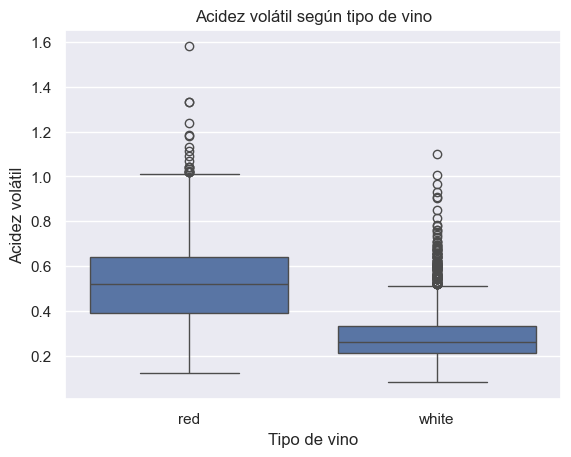

In [48]:
sns.boxplot(data=df, x="tipo_vino", y="volatile_acidity")

plt.title("Acidez volátil según tipo de vino")
plt.xlabel("Tipo de vino")
plt.ylabel("Acidez volátil")

plt.show()

La acidez volátil permite observar diferencias químicas entre vinos rojos y blancos.

# Acidez volatil según la calidad

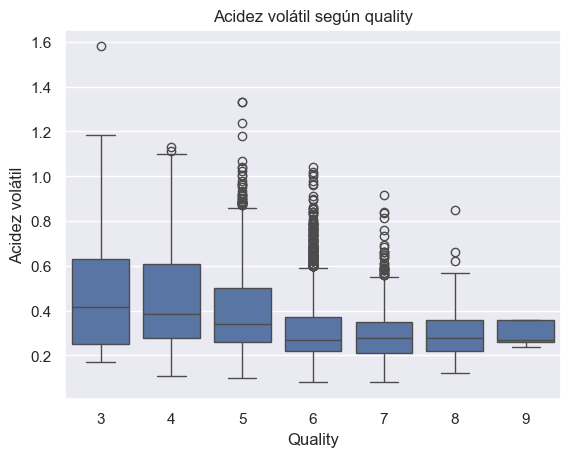

In [49]:
sns.boxplot(data=df, x="quality", y="volatile_acidity")

plt.title("Acidez volátil según quality")
plt.xlabel("Quality")
plt.ylabel("Acidez volátil")

plt.show()

Los vinos con menor calidad presentan mayor acidez volátil. En cambio, los vinos con mayor calidad tienden a presentar menor acidez volátil.

Esto sugiere una relación negativa entre volatile_acidity y quality.

# Correlacion de las variables numericas

La matriz de correlación permite observar la relación entre las variables numéricas seleccionadas. Alcohol suele presentar una correlación positiva con quality, mientras que volatile_acidity suele presentar una correlación negativa con quality. Esto respalda lo observado en los gráficos anteriores.

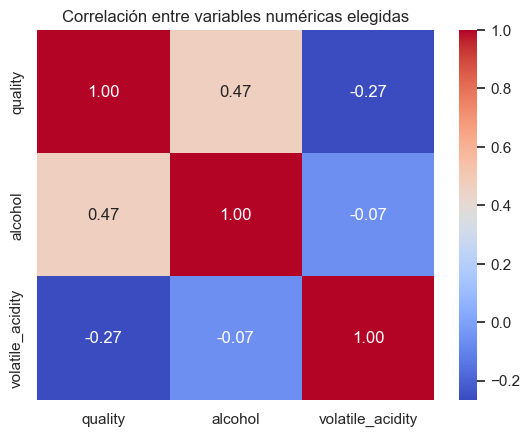

In [51]:
corr = df[["quality", "alcohol", "volatile_acidity"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas elegidas")
plt.show()